<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/K_Nearest_Neighbors_(KNN)_shivam_cs23186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Nearest Neighbors (KNN)

In [4]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
path = '/content/drive/MyDrive/ml_dataset/BreastCancer.csv'
df = pd.read_csv(path)
print('Dataset loaded successfully.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully.


### Data Preparation
First, we need to prepare the data by separating features (`X`) from the target variable (`y`). For the Breast Cancer dataset, `'diagnosis'` is our target. We'll also drop non-contributing columns like `'id'` and `'Unnamed: 32'` (which is often empty).

The `'diagnosis'` column contains categorical values ('M' for Malignant, 'B' for Benign), which need to be converted into numerical representation (e.g., 0 and 1) for the model to process. We'll use `LabelEncoder` for this.

In [5]:
from sklearn.preprocessing import LabelEncoder

# Drop 'id' and 'Unnamed: 32' (if it exists and is mostly empty)
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# Encode the target variable 'diagnosis' (M=1, B=0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y_encoded.shape)
print("Original target classes:", le.classes_)
print("Encoded target classes:", {name: label for name, label in zip(le.classes_, le.transform(le.classes_))})

display(X.head())

Features (X) shape: (569, 30)
Target (y) shape: (569,)
Original target classes: ['B' 'M']
Encoded target classes: {'B': np.int64(0), 'M': np.int64(1)}


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### KNN Experiment Function
To streamline the process and ensure reproducibility, we'll define a function that performs the entire KNN experiment for a given test size and K value. This function will handle data splitting, scaling, model training, prediction, and return key evaluation metrics, including data for the ROC curve.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import numpy as np

def run_knn_experiment(X_data, y_data, k_value, test_size_ratio, random_state=42):
    """
    Runs a KNN classification experiment with specified parameters.

    Args:
        X_data (pd.DataFrame): Features.
        y_data (np.ndarray): Encoded target variable.
        k_value (int): Number of neighbors for KNN.
        test_size_ratio (float): Proportion of the dataset to include in the test split.
        random_state (int): Random state for reproducibility.

    Returns:
        dict: A dictionary containing accuracy, classification report, confusion matrix,
              and ROC curve data (fpr, tpr, roc_auc).
    """
    print(f"\n--- Running KNN experiment with K={k_value}, test_size={test_size_ratio*100}/{(1-test_size_ratio)*100} split ---")

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size_ratio, random_state=random_state, stratify=y_data)

    # Initialize and apply scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k_value)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1] # Probability of the positive class (Malignant=1)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    # ROC curve data
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f"Accuracy Score: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    print(conf_matrix)

    return {
        'accuracy': accuracy,
        'classification_report': class_report,
        'confusion_matrix': conf_matrix,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

### Run KNN Experiments
Now, we'll run the `run_knn_experiment` function for both the 70/30 and 80/20 train-test splits. We'll use `K=5` as a common starting point for the number of neighbors.

In [7]:
# Define K (number of neighbors)
K = 5

# Run experiment with 70/30 split (test_size=0.3)
results_70_30 = run_knn_experiment(X, y_encoded, k_value=K, test_size_ratio=0.3)

# Run experiment with 80/20 split (test_size=0.2)
results_80_20 = run_knn_experiment(X, y_encoded, k_value=K, test_size_ratio=0.2)


--- Running KNN experiment with K=5, test_size=30.0/70.0 split ---
Accuracy Score: 0.9649

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       107
           1       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171


Confusion Matrix:
[[107   0]
 [  6  58]]

--- Running KNN experiment with K=5, test_size=20.0/80.0 split ---
Accuracy Score: 0.9561

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:
[[71  1]
 [ 4 38]]


### Compare Results and Plot ROC Curves
Finally, we'll create a table comparing the key metrics from both experiments and plot their respective ROC curves side-by-side in a single image, as requested.

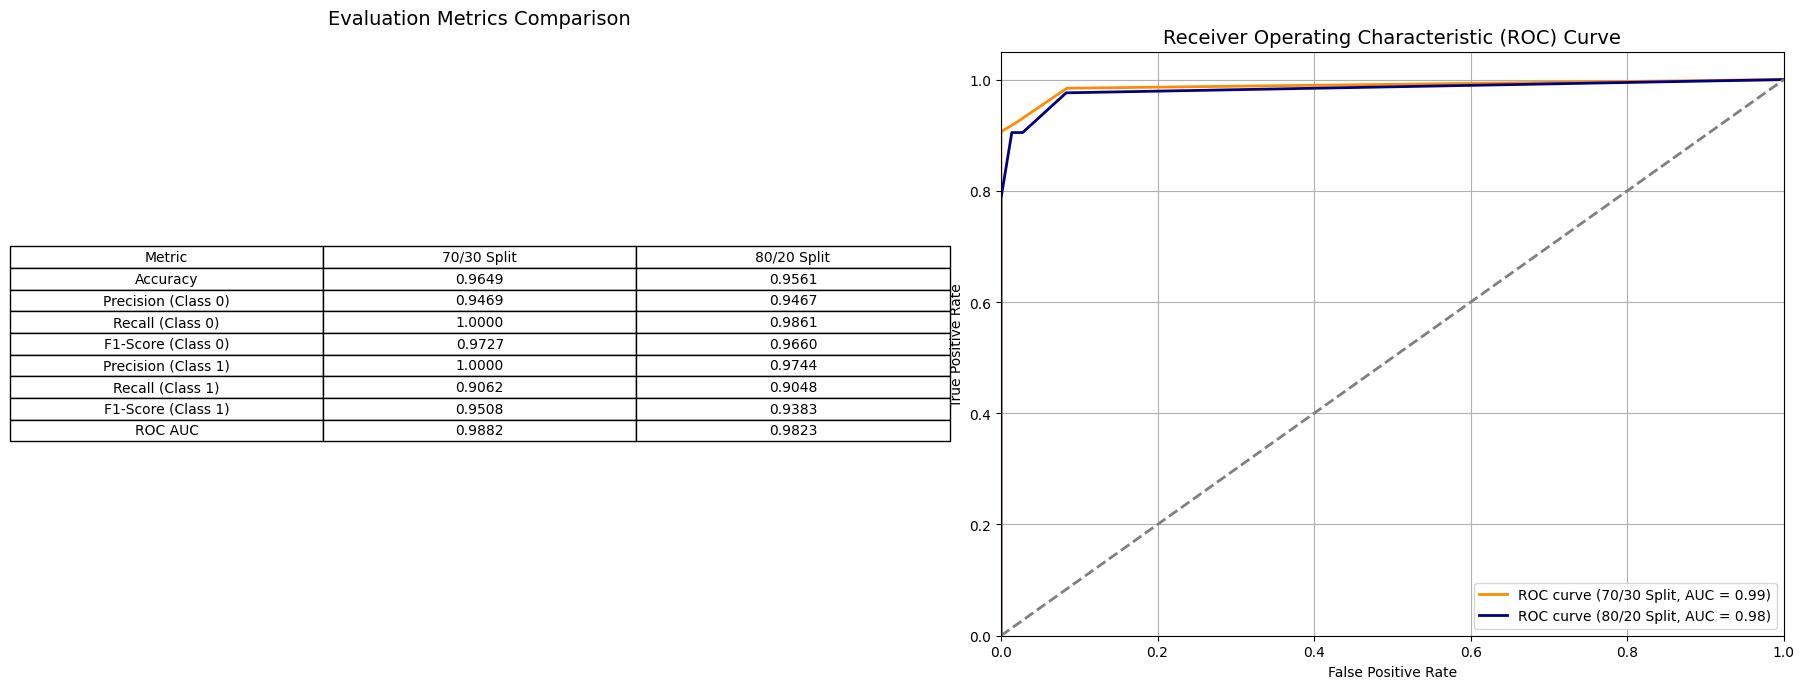

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import io
from PIL import Image
import numpy as np # Import numpy

# Prepare data for the comparison table
data = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'F1-Score (Class 0)',
               'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'ROC AUC'],
    '70/30 Split': [
        results_70_30['accuracy'],
        results_70_30['classification_report']['0']['precision'],
        results_70_30['classification_report']['0']['recall'],
        results_70_30['classification_report']['0']['f1-score'],
        results_70_30['classification_report']['1']['precision'],
        results_70_30['classification_report']['1']['recall'],
        results_70_30['classification_report']['1']['f1-score'],
        results_70_30['roc_auc']
    ],
    '80/20 Split': [
        results_80_20['accuracy'],
        results_80_20['classification_report']['0']['precision'],
        results_80_20['classification_report']['0']['recall'],
        results_80_20['classification_report']['0']['f1-score'],
        results_80_20['classification_report']['1']['precision'],
        results_80_20['classification_report']['1']['recall'],
        results_80_20['classification_report']['1']['f1-score'],
        results_80_20['roc_auc']
    ]
}

df_comparison = pd.DataFrame(data)

# Create a new list of lists for cellText, applying rounding to numbers
cell_text_data = []
for index, row in df_comparison.iterrows():
    row_formatted = []
    for col_name in df_comparison.columns:
        value = row[col_name]
        if isinstance(value, (float, np.number)): # Check if value is numeric
            row_formatted.append(f"{value:.4f}") # Format numerical values to 4 decimal places
        else:
            row_formatted.append(str(value)) # Convert other types (like strings) to string
    cell_text_data.append(row_formatted)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Subplot 1: Table
# Hide axes
axes[0].axis('off')
axes[0].axis('tight')

# Create table and add to subplot
table = axes[0].table(cellText=cell_text_data, # Use the manually formatted list of lists
                      colLabels=df_comparison.columns,
                      loc='center',
                      cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
axes[0].set_title('Evaluation Metrics Comparison', fontsize=14, pad=20)

# Subplot 2: ROC Curves
axes[1].plot(results_70_30['fpr'], results_70_30['tpr'], color='darkorange', lw=2, label=f'ROC curve (70/30 Split, AUC = {results_70_30["roc_auc"]:.2f})')
axes[1].plot(results_80_20['fpr'], results_80_20['tpr'], color='navy', lw=2, label=f'ROC curve (80/20 Split, AUC = {results_80_20["roc_auc"]:.2f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()